# Example 3.7: Monte Carlo simulation of stochastic time series with a given auto spectral density
In this example, we will show procedures to make realisations of a stationary stochastic process with a given auto-spectral density. 

## Auto spectral density

We start by defining the auto spectral density that we will consider in this example. This is a (one-sided!) spectrum used to describe wave elevations in the North Sea:

$$
S_X(\omega) = 
\alpha g^2  \omega^{-5}
\exp \left(- \dfrac{5}{4} \left( \dfrac{\omega_m}{\omega} \right)^{4} \right)
$$

Here, $g=9.81$, $\alpha=8.1 \cdot 10^{-3}$, and $\omega_m$ is a parameter that controls where the peak of the spectral density is located. We set $\omega_m=0.6$.

The auto-spectral density is defined and plotted below.

Text(0.5, 0, '$\\omega$ [rad/s]')

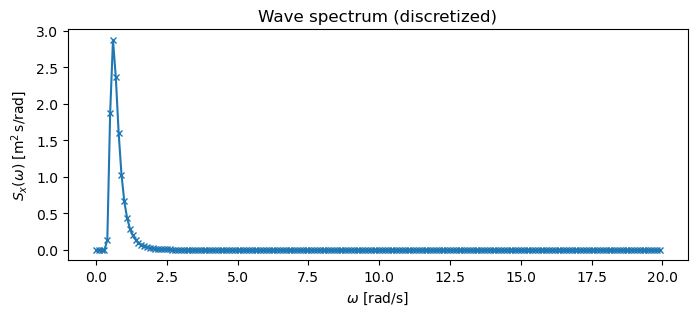

In [7]:
import numpy as np
from matplotlib import pyplot as plt
import time

omega_max = 20.0  # Highest angular frequency represented [rad/s]
domega = 0.1      # Angular-frequency spacing [rad/s]
omega = np.arange(0, omega_max, domega)
N = len(omega)

g=9.81
alpha=8.1e-3
omega_m=0.6

Sx = np.zeros_like(omega)
positive = omega > 0
Sx[positive] = (alpha*g**2*omega[positive]**-5
                * np.exp(-5/4*(omega_m/omega[positive])**4))

plt.figure(figsize=(8,3))
plt.plot(omega,Sx,marker='x',markersize=5)
#plt.stem(omega,Sx,'o')
plt.title('Wave spectrum (discretized)')
plt.ylabel(r'$S_x(\omega)$ [$\mathrm{m^2\,s/rad}$]')
plt.xlabel(r'$\omega$ [rad/s]')



## Method 1: Sum of cosine terms
The following formula can obtain realizations of the stochastic process.

$$x(t) = \sum_{k=0}^{N-1}  A_k \cos (\omega_kt + \phi_k) $$

$$A_k = \sqrt{2 S_x(\omega_k) \Delta \omega} $$

Here, $S_x(\omega_k)$ is the one-sided auto-spectral density of the process, and the phase angles $\phi_k$ are uniformly distributed between $0$ and $2\pi$.

The frequency spacing determines the record duration, while the largest represented frequency determines the required sampling interval:

$$T=\frac{2\pi}{\Delta\omega}, \qquad \Delta t \leq \frac{\pi}{\omega_{\max}}.$$

We use equality in the sampling condition. Thus $N_t=T/\Delta t$ time samples cover one periodic record, and the Nyquist angular frequency is $\omega_N=\pi/\Delta t=\omega_{\max}$. The spectral grid stops one bin below $\omega_{\max}$, so every simulated harmonic lies strictly below Nyquist. Finally, the area under the one-sided spectrum gives the theoretical variance:

$$\sigma_X^2 = \int_0^\infty S_X(\omega)\,d\omega \approx \sum_k S_X(\omega_k)\Delta\omega.$$

Spent time = 6.67 ms


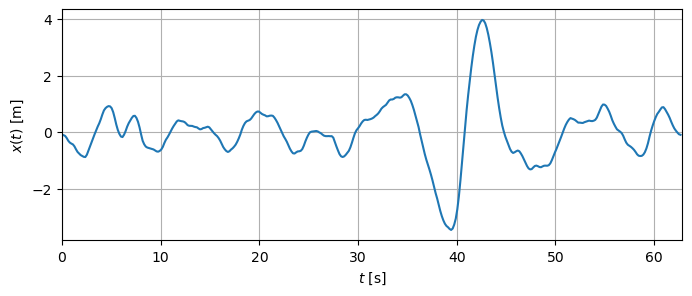

In [8]:
T = 2*np.pi/domega            # Record duration [s]
dt = np.pi/omega_max          # Nyquist-safe sampling interval [s]
n_time = int(round(T/dt))     # Number of time samples

t0=time.time()
t = np.arange(n_time)*dt # Time vector [s]
phi = np.random.rand(N)*2*np.pi # Random phase angles 

x = np.zeros_like(t) # Initialize the vector of x values
for k in range(N):
    Ak = (2*Sx[k]*domega)**0.5 #Amplitude
    x = x + Ak * np.cos(omega[k]*t+phi[k]) # Sum the contribution from each harmonic component
t1=time.time()

print(f'Spent time = {(t1-t0)*1000:.2f} ms')

plt.figure(figsize=(8,3))
plt.plot(t,x)
plt.ylabel(r'$x(t)$ [m]')
plt.xlabel(r'$t$ [s]')
plt.xlim(0,T)
plt.grid()


We observe that the realization indeed looks like a random process. Try changing the frequency spacing or the maximum in the $\omega$-axis, and see how that influences the time-domain properties of the simulated time series.

We can also plot the individual frequency components. 

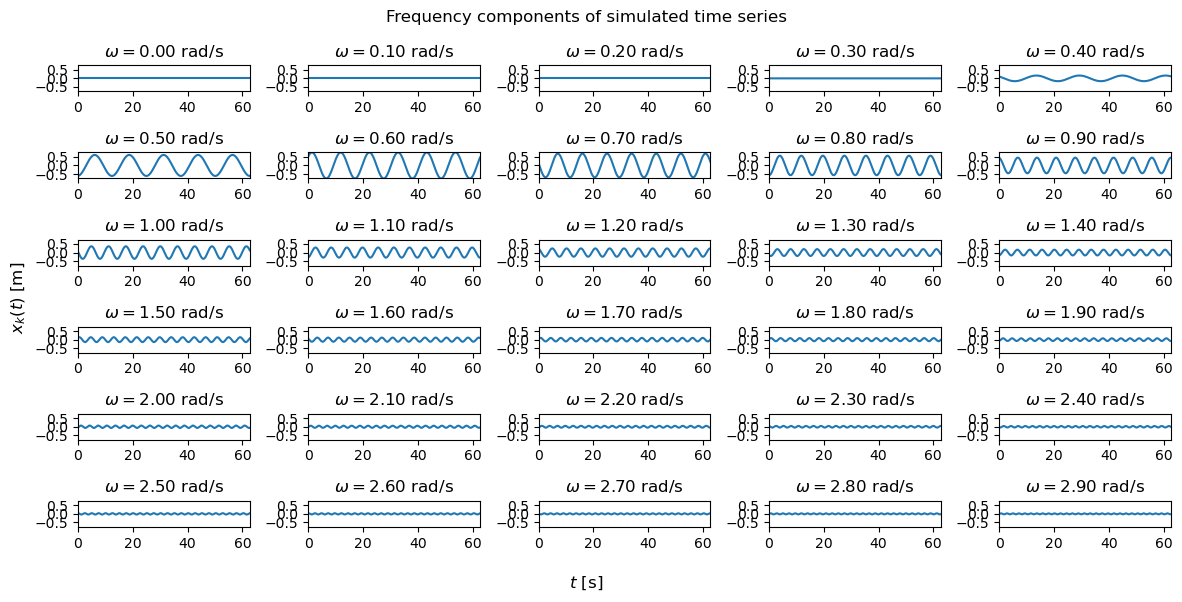

In [9]:
# Plot the 30 first harmonic contributions
fig, axs = plt.subplots(6, 5, figsize=(12, 6))
fig.suptitle('Frequency components of simulated time series')

k=-1
for i in range(6):
    for j in range(5):
        k=k+1
        Ak = (2*Sx[k]*domega)**0.5
        axs[i,j].plot(t,Ak * np.cos(omega[k]*t+ phi[k]))
        axs[i,j].set_title(r'$\omega=$' + '{:.2f} rad/s'.format(omega[k]))

        axs[i,j].set_xlim(0,np.max(t))
        axs[i,j].set_ylim(np.max((2*Sx*domega)**0.5)*np.array([-1.0,1.0]))
        
fig.supxlabel(r'$t$ [s]')
fig.supylabel(r'$x_k(t)$ [m]')
plt.tight_layout()


The cosine waves with lowest frequencies contribute little since $S(\omega)$ has no energy here. The greatest contributions comes from $\omega \in [0.4,1]$ rad/s, where the wave energy is concentrated. Notice that all cosine waves also have different phase angles: some start with a peak at $t=0$, others start with a dip, and so on.

## Method 2: The inverse fast Fourier transform (IFFT)
It is also possible to use the IFFT to calculate the realizations of the stochastic process. This is a considerable advantage since this approach is much faster than the cosine-sum method shown above. We start by rewriting the cosine-sum expression slightly:

$$
\begin{align}
x(t) &= \sum_{k=0}^{N-1} A_k \cos(\omega_k t + \phi_k) \\
&= \Re \left(\sum_{k=0}^{N-1}  A_k e^{i (\omega_k t + \phi_k)} \right) \\
&= \Re \left(\sum_{k=0}^{N-1}  A_k e^{i \phi_k}e^{i \omega_k t}  \right)
\end{align}
$$

Here we recognize the inverse discrete Fourier transform. A real-valued time series requires conjugate symmetry: the coefficient at each negative frequency must be the complex conjugate of the corresponding positive-frequency coefficient. With NumPy's inverse-transform normalization, the coefficient for each positive-frequency bin is

$$C_k = \frac{N_t}{2} A_k e^{i\phi_k}, \qquad C_{N_t-k}=C_k^*, \qquad x_n=\Re\{\operatorname{IFFT}(C_k)\}.$$

The DC and Nyquist coefficients are set to zero for the present spectrum. We then construct the complete two-sided coefficient vector explicitly before applying the IFFT.

The code below shows an example:


Spent time = 3.53 ms


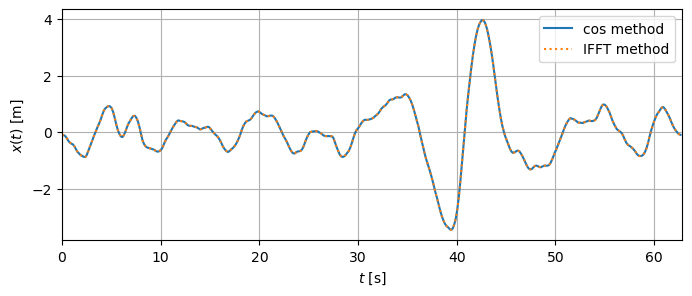

In [10]:

t0=time.time()
Ak = np.sqrt(2*Sx*domega)
c = np.zeros(n_time, dtype=complex)
c[1:N] = n_time/2 * Ak[1:] * np.exp(1j*phi[1:])
c[-(N-1):] = np.conj(c[1:N][::-1])  # Negative-frequency coefficients
x_ifft = np.real(np.fft.ifft(c))
t1=time.time()

print(f'Spent time = {(t1-t0)*1000:.2f} ms')

plt.figure(figsize=(8,3))
plt.plot(t,x,label= 'cos method')
plt.plot(t,x_ifft,label = 'IFFT method',linestyle=':')
plt.ylabel(r'$x(t)$ [m]')
plt.xlabel(r'$t$ [s]')
plt.xlim(0,T)
plt.grid()
plt.legend()


The figure above shows the realisation obtained by IFFT compared to the time series obtained by summing cosine terms. The time series are equal because the two methods are equal, and the same phase angles have been used to generate both. Try using different phase angles by running the cells one more time and investigating how realisations differ.

## Validation of process variance

The area under the one-sided auto-spectral density gives the process variance. The corresponding standard deviation is

$$\sigma_X = \sqrt{\int_0^\infty S_X(\omega)\,d\omega} \approx \sqrt{\sum_k S_X(\omega_k)\Delta\omega}.$$

We compare this value with the standard deviations of the time series generated by Method 1 and Method 2. Because the record contains complete periods of all frequency components, the values should agree closely.